<a href="https://colab.research.google.com/github/amasha-sinhalagoda/J26-IT-334/blob/model%2Fcp_landslide/Landslide_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*This is My NoteBook that I Implement and Build My Model . My component Is Landslide Risk Assetment For Sri Lanka - Bagya R M S*

*Importing libraries That Need For implementations*

In [2]:
import pandas as pd

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
sns.set_theme(style='whitegrid')

*Import Datasets Into my Note Book landslide_rainfall_model_dataset*

In [4]:
df = pd.read_csv('/content/landslide_static_model_dataset.csv')

print(df.shape)
display(df.head())
print(df.info())

(5597, 17)


,label,fold,block_id,soil_clay_0_30,soil_sand_0_30,soil_silt_0_30,soil_oc_0_30,soil_ph_0_30,soil_bd_0_30,soil_awc_0_30,soil_clay_gradient,soil_cec_0_30,soil_clay_60_100,bench_lhmp_class,diag_nearest_gauge_km,meta_lat,meta_lon
0,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.70095,7.098072,80.756045
1,1,4,65_70,23.84051,54.35036,20.01871,1.51113,5.39450,1.25873,0.05892,8.00685,14.15983,29.81838,3.0,1.07428,7.109057,80.746482
2,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.63560,7.099661,80.755744
3,1,4,65_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.39824,7.098072,80.753045
4,1,3,67_72,22.30682,57.88093,18.38064,1.51489,5.55341,1.28142,0.05545,7.89976,14.52311,28.72892,1.0,5.44532,7.151016,80.790857


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5597 entries, 0 to 5596
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   label                  5597 non-null   int64  
 1   fold                   5597 non-null   int64  
 2   block_id               5597 non-null   object 
 3   soil_clay_0_30         5597 non-null   float64
 4   soil_sand_0_30         5597 non-null   float64
 5   soil_silt_0_30         5597 non-null   float64
 6   soil_oc_0_30           5597 non-null   float64
 7   soil_ph_0_30           5597 non-null   float64
 8   soil_bd_0_30           5597 non-null   float64
 9   soil_awc_0_30          5597 non-null   float64
 10  soil_clay_gradient     5597 non-null   float64
 11  soil_cec_0_30          5597 non-null   float64
 12  soil_clay_60_100       5597 non-null   float64
 13  bench_lhmp_class       5427 non-null   float64
 14  diag_nearest_gauge_km  5597 non-null   float64
 15  meta

In [ ]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))
print(df.isnull().sum())
print(df['fold'].value_counts())

label
0    4398
1    1199
Name: count, dtype: int64
label
0    0.785778
1    0.214222
Name: proportion, dtype: float64
label                      0
fold                       0
block_id                   0
soil_clay_0_30             0
soil_sand_0_30             0
soil_silt_0_30             0
soil_oc_0_30               0
soil_ph_0_30               0
soil_bd_0_30               0
soil_awc_0_30              0
soil_clay_gradient         0
soil_cec_0_30              0
soil_clay_60_100           0
bench_lhmp_class         170
diag_nearest_gauge_km      0
meta_lat                   0
meta_lon                   0
dtype: int64
fold
0    1196
4    1150
1    1105
3    1094
2    1052
Name: count, dtype: int64


*Check Class Imbalance and Missing Values*

In [5]:
print('landslide share:', round(df.label.mean(), 3))
print(df.label.value_counts())
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

landslide share: 0.214
label
0    4398
1    1199
Name: count, dtype: int64

missing values:
bench_lhmp_class    170
dtype: int64


*Check The spatial folds*

In [6]:
blocks_in_many_folds = (df.groupby('block_id').fold.nunique() > 1).sum()
print('blocks in more than one fold:', blocks_in_many_folds)

df.groupby('fold').label.agg(rows='size', landslides='sum', share='mean').round(3)

blocks in more than one fold: 0


,rows,landslides,share
fold,,,
0,1196,212,0.177
1,1105,317,0.287
2,1052,143,0.136
3,1094,147,0.134
4,1150,380,0.330


*Find the duplication Rows*

In [7]:
print('exact duplicate rows:', df.duplicated().sum())
print('duplicates among landslides:', df[df.label == 1].duplicated().sum())
print('duplicates among non-landslides:', df[df.label == 0].duplicated().sum())

exact duplicate rows: 160
duplicates among landslides: 160
duplicates among non-landslides: 0


*Remove That found Dupliation Rows*

In [8]:
clean = df.drop_duplicates().reset_index(drop=True)
print('after removing duplicates:', clean.shape)
print('landslides:', int(clean.label.sum()), '| share:', round(clean.label.mean(), 3))
clean.to_csv('static_clean_step1.csv', index=False)

after removing duplicates: (5437, 17)
landslides: 1039 | share: 0.191


*define feature groups and check correlation*

['soil_clay_0_30', 'soil_sand_0_30', 'soil_silt_0_30', 'soil_oc_0_30', 'soil_ph_0_30', 'soil_bd_0_30', 'soil_awc_0_30', 'soil_clay_gradient', 'soil_cec_0_30', 'soil_clay_60_100']


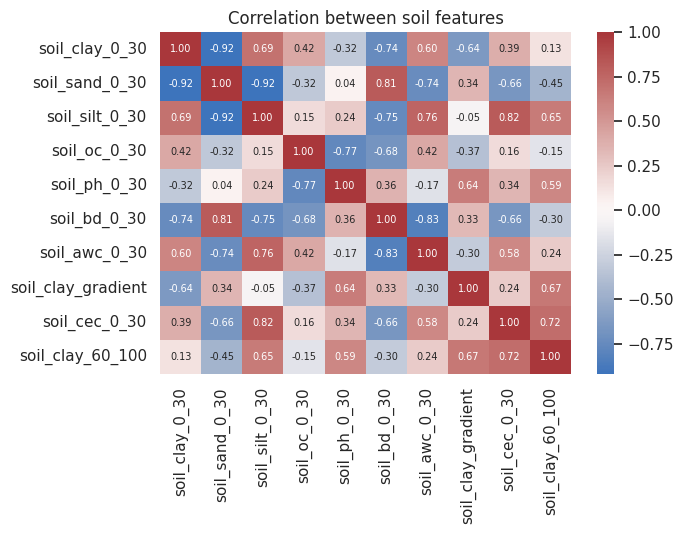

In [9]:
SOIL = [c for c in clean.columns if c.startswith('soil_')]
print(SOIL)

plt.figure(figsize=(7, 5.5))
sns.heatmap(clean[SOIL].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, annot_kws={'size': 7})
plt.title('Correlation between soil features')
plt.tight_layout()
plt.show()

In [10]:
print('unique soil vectors:', clean[SOIL].drop_duplicates().shape[0], 'of', len(clean), 'rows')

clean.groupby('label')[SOIL].mean().T.round(2)

unique soil vectors: 1570 of 5437 rows


label,0,1
soil_clay_0_30,22.74,22.90
soil_sand_0_30,57.61,57.21
soil_silt_0_30,18.35,18.65
soil_oc_0_30,2.08,2.05
soil_ph_0_30,5.29,5.31
soil_bd_0_30,1.23,1.22
soil_awc_0_30,0.06,0.06
soil_clay_gradient,5.27,5.55
soil_cec_0_30,14.19,14.51
soil_clay_60_100,26.31,27.02


***distribution plots***

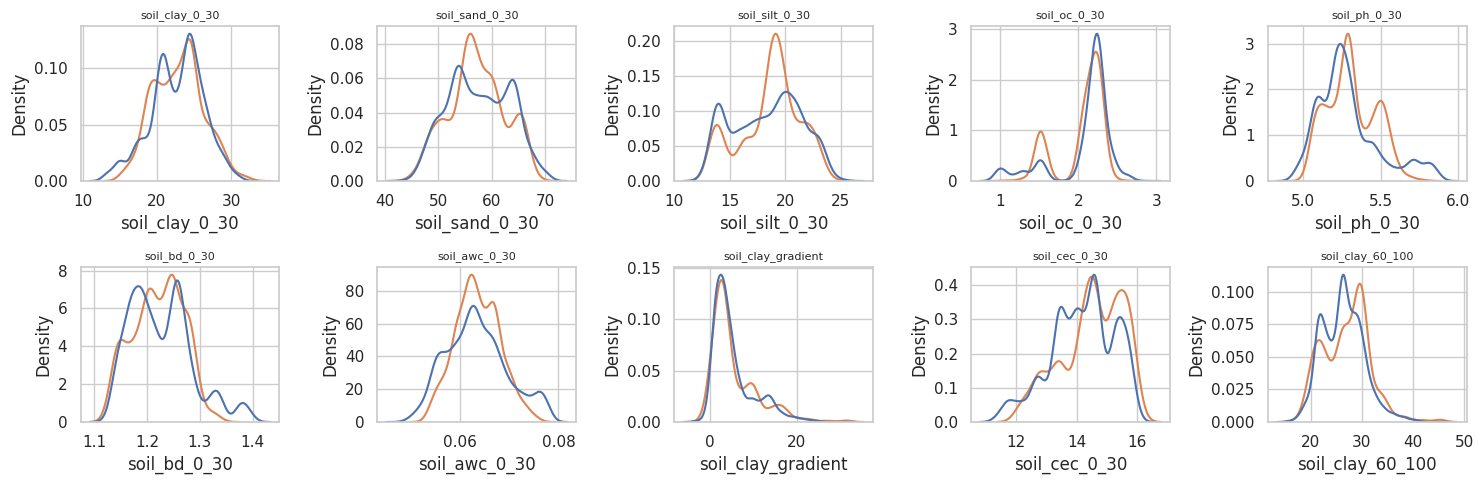

In [11]:
fig, ax = plt.subplots(2, 5, figsize=(15, 5))
for a, c in zip(ax.ravel(), SOIL):
    sns.kdeplot(data=clean, x=c, hue='label', common_norm=False, ax=a, legend=False)
    a.set_title(c, fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
b = clean.dropna(subset=['bench_lhmp_class'])
print('NBRI hazard class AUC:', round(roc_auc_score(b.label, b.bench_lhmp_class), 3))
pd.crosstab(b.bench_lhmp_class, b.label, normalize='index').round(2)

NBRI hazard class AUC: 0.512


label,0,1
bench_lhmp_class,,
1.0,0.82,0.18
2.0,0.80,0.20
3.0,0.81,0.19
4.0,0.79,0.21


***load the cleaned data and define features***

In [14]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
df = pd.read_csv('static_clean_step1.csv')
y = df.label.values

SOIL   = [c for c in df.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']   # drop sand for logistic regression
COORDS = ['meta_lat', 'meta_lon']
print(len(df), 'rows |', int(y.sum()), 'landslides')

5437 rows | 1039 landslides
